# Tobacco Data Gateway — Beispielabfragen

Dieses Notebook zeigt die drei Zugänge: den harmonisierten Datensatz, die deterministische Frage-Engine und den Rohdaten-Abruf je Quelle.

Ausführen im Repo-Root mit aktivierter venv: `.venv/bin/jupyter lab notebooks/example_queries.ipynb`

In [1]:
import sys
sys.path.insert(0, '..')  # Repo-Root, wenn aus notebooks/ gestartet

import pandas as pd
import matplotlib.pyplot as plt
from tobacco_gateway import answer, load_indicators, select_indicators, fetch, query

df = load_indicators()
print(df.shape)
df.groupby(['indicator_id', 'geo_level']).size().unstack(fill_value=0)

(4804, 20)


geo_level,city,country,germany,region,state
indicator_id,,,,,
htp_current,0,0,1,0,0
lung_cancer_incidence,0,0,525,0,1200
lung_cancer_mortality,0,0,564,0,1200
passive_smoking,0,0,55,30,0
smoking_current,1,0,154,2,140
smoking_daily,1,0,44,0,48
smoking_former,1,0,42,0,48
smoking_heavy,0,0,41,0,45
smoking_never,1,0,42,0,0


## 1. Eine Frage stellen

`answer()` wählt Indikator, Gebiet und Aufschlüsselung per Stichwort und formuliert eine Antwort aus den gefundenen Zeilen. Es werden keine Zahlen erfunden; fehlt etwas, sagt die Antwort das.

In [2]:
for q in ['Wie viele Menschen rauchen in Bayern?',
          'Rauchen nach Bildung in Deutschland',
          'Rauchen in München',
          'E-Zigaretten in Bayern']:
    a = answer(q, df)
    print(q)
    print('  ->', a.text[:300], '\n')

Wie viele Menschen rauchen in Bayern?
  -> Rauchen (täglich oder gelegentlich) in Bayern: 20,5 % (2017; Quelle: destatis_mikrozensus). Rauchen (täglich oder gelegentlich) in Bayern: 26,4 % (2019/2020; Quelle: rki_gbe_ncd). Hinweis: GEDA 2019/2020-EHIS; Erwachsene ab 18 Jahren | Mikrozensus 2017 (freiwillige Gesundheitsfragen); Bevölkerung ab 

Rauchen nach Bildung in Deutschland
  -> Rauchen (täglich oder gelegentlich) in Deutschland nach Bildung (2012; Quelle: rki_diabetes_surveillance): gesamt: 27,6 %, hoch: 19,0 %, mittel: 30,5 %, niedrig: 27,5 %. Rauchen (täglich oder gelegentlich) in Deutschland nach Bildung (2019/2020; Quelle: rki_gbe_ncd): gesamt: 28,9 %, hoch: 17,3 %, mi 

Rauchen in München
  -> Rauchen (täglich oder gelegentlich) in München (insgesamt, 2016): 18,0 %. Quelle: muenchen_gesundheitsbefragung, Münchner Statistik 3. Quartalsheft 2016, S. 12 (PDF-Seite 14), Grafik 13. Hinweis: Summe aus täglich (12 %) und gelegentlich (6 %) Rauchenden; Schwerpunktbefragung der Münch

## 2. Zeitreihe: Lungenkrebs-Sterblichkeit in Bayern und Deutschland

Altersstandardisierte Sterbefälle je 100.000 (RKI GBE, Todesursachenstatistik).

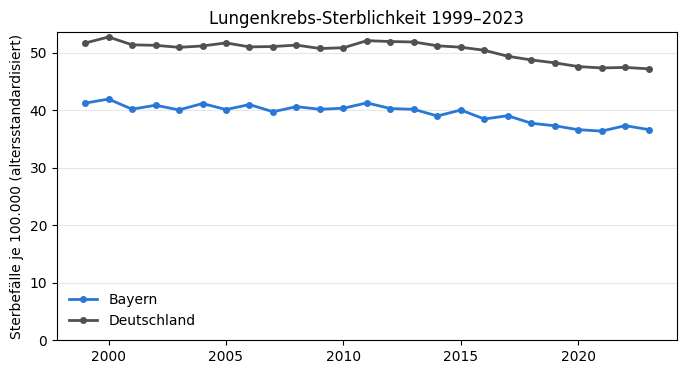

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for geo, color in [('Bayern', '#2a78d6'), ('Deutschland', '#52514e')]:
    d = select_indicators(df, 'lung_cancer_mortality', geo=geo, breakdown='year')
    ax.plot(d['year'], d['value'], marker='o', ms=4, lw=2, color=color, label=geo)
ax.set_ylim(0, None); ax.set_ylabel('Sterbefälle je 100.000 (altersstandardisiert)')
ax.set_title('Lungenkrebs-Sterblichkeit 1999–2023'); ax.legend(frameon=False); ax.grid(axis='y', alpha=.3)
plt.show()

## 3. Sozio-demografisch: Rauchen nach Bildung und Geschlecht (GEDA 2019/2020)

In [4]:
d = select_indicators(df, 'smoking_current', geo='Deutschland', breakdown='education')
d[['education', 'value', 'ci_lower', 'ci_upper', 'n', 'period', 'source_id']]

,education,value,ci_lower,ci_upper,n,period,source_id
0,gesamt,27.6,26.70,28.48,NaN,2012,rki_diabetes_surveillance
1,hoch,19.0,17.79,20.36,NaN,2012,rki_diabetes_surveillance
2,mittel,30.5,29.33,31.75,NaN,2012,rki_diabetes_surveillance
3,niedrig,27.5,25.76,29.40,NaN,2012,rki_diabetes_surveillance
4,gesamt,28.9,27.90,29.90,22699.0,2019/2020,rki_gbe_ncd
5,hoch,17.3,16.20,18.50,8398.0,2019/2020,rki_gbe_ncd
6,mittel,31.8,30.40,33.20,9966.0,2019/2020,rki_gbe_ncd
7,niedrig,31.0,28.90,33.10,4275.0,2019/2020,rki_gbe_ncd


In [5]:
rows = []
for sex in ['gesamt', 'männlich', 'weiblich']:
    d = select_indicators(df, 'smoking_current', geo='Bayern', sex=sex)
    rows.append(d[['geo_name', 'period', 'sex', 'value', 'source_id']])
pd.concat(rows).sort_values(['source_id', 'sex'])

,geo_name,period,sex,value,source_id
0,Bayern,2017,gesamt,20.51,destatis_mikrozensus
0,Bayern,2017,männlich,24.57,destatis_mikrozensus
0,Bayern,2017,weiblich,16.55,destatis_mikrozensus
1,Bayern,2019/2020,gesamt,26.40,rki_gbe_ncd
1,Bayern,2019/2020,männlich,29.50,rki_gbe_ncd
1,Bayern,2019/2020,weiblich,23.50,rki_gbe_ncd


## 4. Geografisch: Bundesländer im Vergleich (Mikrozensus 2017, Bevölkerung ab 15 Jahren)

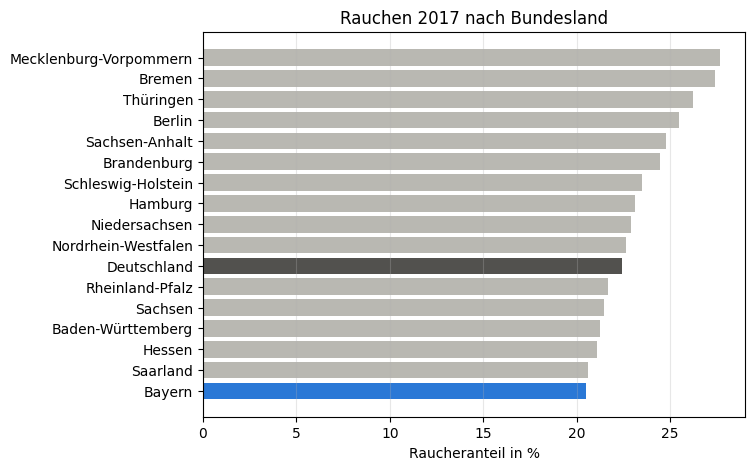

In [6]:
d = select_indicators(df, 'smoking_current', breakdown='geo_name')
d = d[d['source_id'] == 'destatis_mikrozensus'].sort_values('value')
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#2a78d6' if g == 'Bayern' else '#52514e' if g == 'Deutschland' else '#b9b8b2' for g in d['geo_name']]
ax.barh(d['geo_name'], d['value'], color=colors)
ax.set_xlabel('Raucheranteil in %'); ax.set_title('Rauchen 2017 nach Bundesland'); ax.grid(axis='x', alpha=.3)
plt.show()

## 5. Rohdaten einer Quelle

`fetch()` liefert die Originaltabelle (Cache in `data/`). Quellen, die eine Registrierung oder Datennutzungsvereinbarung erfordern, geben eine Anleitung statt Daten.

In [7]:
mz = fetch('destatis_mikrozensus')  # Mikrozensus 2017, Tab 1, in 1000 Personen
total = mz[mz['sex'] == 'Insgesamt'].copy()
total['smoker_pct'] = total['smokers_total_1000'] / total['pop_with_data_1000'] * 100
total[['age_group', 'smoker_pct']].round(1)

,age_group,smoker_pct
34,15 - 20,10.8
35,20 - 25,25.3
36,25 - 30,29.9
37,30 - 35,30.7
38,35 - 40,30.2
39,15 - 40,26.1
40,40 - 45,28.3
41,45 - 50,28.5
42,50 - 55,28.8
43,55 - 60,27.6


In [8]:
for src in ['rki_geda', 'staba_mikrozensus', 'eurobarometer_tobacco']:
    try:
        r = fetch(src)
        print(f'{src}: {len(r)} Zeilen')
    except (RuntimeError, FileNotFoundError) as e:
        print(f'{src}: manueller Schritt nötig — {str(e).splitlines()[0]}')

rki_geda: 258 Zeilen
staba_mikrozensus: manueller Schritt nötig — GENESIS Bayern no longer allows anonymous downloads.
eurobarometer_tobacco: manueller Schritt nötig — Eurobarometer tobacco microdata requires a free GESIS account.


## 6. Welche Quelle passt zu einer Frage? (Katalogsuche über SOURCE.md)

In [9]:
for r in query('E-Zigaretten Jugendliche Bayern')[:5]:
    print(f'{r.score:3d}  {r.source_id:32s} {r.geographic_level}')

  4  bgs_bayern                       bavaria
  4  gesundheitsatlas_bayern          bavaria
  4  staba_mikrozensus                bavaria
  2  muenchen_gesundheitsbefragung    munich
  2  muenchen_gesundheitsbericht      munich
